📊 DATASET
    Study_Hours  Attendance  Assignments  Result
0           1.0          45            1       0
1           1.5          48            2       0
2           2.0          52            2       0
3           2.5          55            3       0
4           3.0          58            3       0
5           3.5          60            4       0
6           4.0          64            4       1
7           4.5          68            5       1
8           5.0          70            5       1
9           5.5          73            6       1
10          6.0          76            6       1
11          6.5          80            7       1
12          7.0          84            8       1
13          8.0          88            8       1
14          9.0          92            9       1
15         10.0          96           10       1

🔍 DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column       Non-Null Count  D

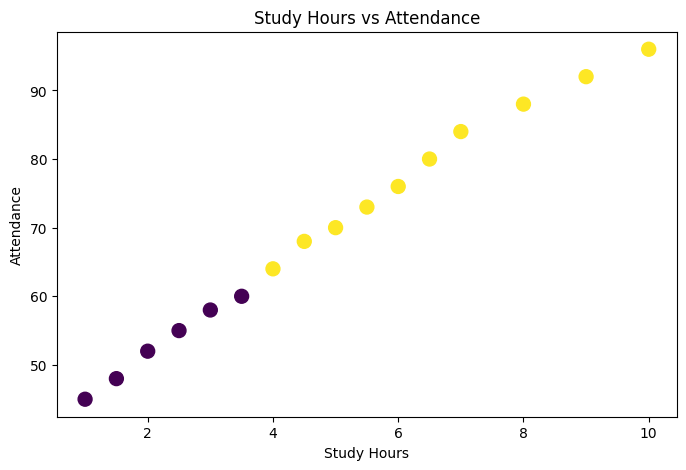


📚 TRAINING SAMPLES: 12
🧪 TESTING SAMPLES : 4

🤖 MODEL TRAINING COMPLETED!

📈 MODEL PERFORMANCE
Accuracy: 1.0

🔲 CONFUSION MATRIX
[[2 0]
 [0 2]]

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


🎓 NEW STUDENT PREDICTION: PASS


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# 🚀 Day 29 - End-to-End Machine Learning Project
# Student Performance Prediction

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# -----------------------------------------------------
# 1. CREATE DATASET
# -----------------------------------------------------

data = {
    "Study_Hours": [
        1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5,
        5, 5.5, 6, 6.5, 7, 8, 9, 10
    ],

    "Attendance": [
        45, 48, 52, 55, 58, 60, 64, 68,
        70, 73, 76, 80, 84, 88, 92, 96
    ],

    "Assignments": [
        1, 2, 2, 3, 3, 4, 4, 5,
        5, 6, 6, 7, 8, 8, 9, 10
    ],

    "Result": [
        0, 0, 0, 0, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

print("📊 DATASET")
print(df)

# -----------------------------------------------------
# 2. BASIC DATA UNDERSTANDING
# -----------------------------------------------------

print("\n🔍 DATA INFORMATION")
print(df.info())

print("\n📈 STATISTICAL SUMMARY")
print(df.describe())

print("\n❓ MISSING VALUES")
print(df.isnull().sum())

# -----------------------------------------------------
# 3. EDA
# -----------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study_Hours"],
    df["Attendance"],
    c=df["Result"],
    s=100
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Study Hours vs Attendance")

plt.show()

# -----------------------------------------------------
# 4. FEATURES AND TARGET
# -----------------------------------------------------

X = df[
    ["Study_Hours", "Attendance", "Assignments"]
]

y = df["Result"]

# -----------------------------------------------------
# 5. TRAIN-TEST SPLIT
# -----------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\n📚 TRAINING SAMPLES:", len(X_train))
print("🧪 TESTING SAMPLES :", len(X_test))

# -----------------------------------------------------
# 6. FEATURE SCALING
# -----------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------------------------------
# 7. TRAIN MODEL
# -----------------------------------------------------

model = LogisticRegression()

model.fit(
    X_train_scaled,
    y_train
)

print("\n🤖 MODEL TRAINING COMPLETED!")

# -----------------------------------------------------
# 8. PREDICTIONS
# -----------------------------------------------------

y_pred = model.predict(X_test_scaled)

# -----------------------------------------------------
# 9. MODEL EVALUATION
# -----------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n📈 MODEL PERFORMANCE")
print("Accuracy:", round(accuracy, 2))

print("\n🔲 CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

print("\n📋 CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

# -----------------------------------------------------
# 10. PREDICT NEW STUDENT
# -----------------------------------------------------

new_student = [[
    6,      # Study Hours
    82,     # Attendance
    7       # Assignments
]]

new_student_scaled = scaler.transform(
    new_student
)

prediction = model.predict(
    new_student_scaled
)

if prediction[0] == 1:
    print("\n🎓 NEW STUDENT PREDICTION: PASS")
else:
    print("\n🎓 NEW STUDENT PREDICTION: FAIL")